/var/folders/lf/shxhtlcn7xz292_btwwwc6640000gn/T/ipykernel_2157/3919036966.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 0.9, 0.96])  # leave space for colorbar and legend


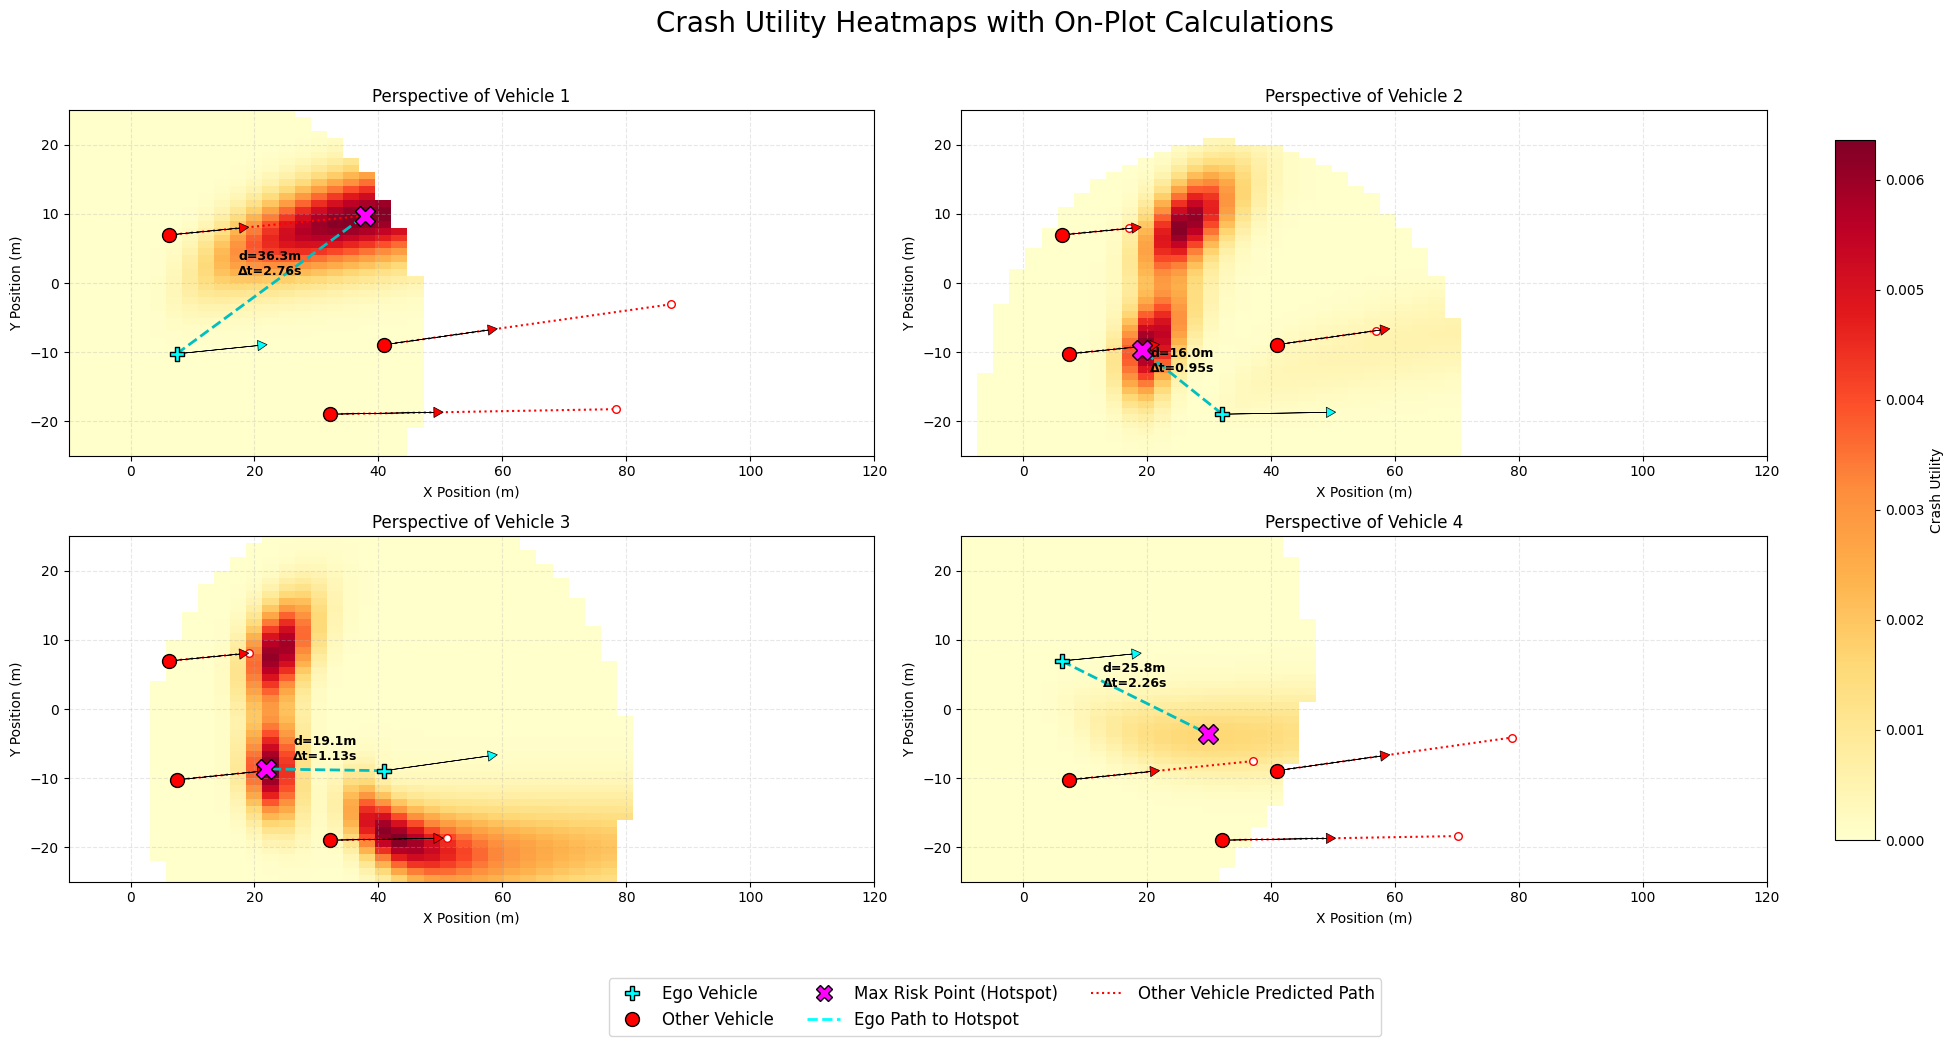

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D  # Import for creating custom legend handles

# --- 1. Initial Setup and Parameters ---

# Initialize grid dimensions
grid_size = 50
x = np.linspace(-10, 120, grid_size)
y = np.linspace(-25, 25, grid_size)

# Parameters for the utility function and simulation
S_theta, S_v, alpha, xi, w_c = 1.0, 1.0, 0.01, 2.0, 0.5
perception_radius = 40  # Perception horizon radius in grid units
num_vehicles = 4

# Initialize vehicle properties with some randomness
initial_vehicles = []
for i in range(num_vehicles):
    vehicle = {
        'position': np.array([np.random.uniform(0, 50), np.random.uniform(-20, 20)]),
        'velocity': np.array([np.random.uniform(10, 20), np.random.uniform(-2.5, 2.5)]),
        'target': np.array([np.random.uniform(180, 200), np.random.uniform(-20, 20)])
    }
    initial_vehicles.append(vehicle)

# --- 2. Function Definitions ---

### Crash Utility with Dynamic Time Step ###
def calculate_crash_utility(grid_x, grid_y, current_vehicle, vehicles, sigma=5.0, epsilon=1e-5):
    crash_utility = 0.0
    
    dx_i = grid_x - current_vehicle['position'][0]
    dy_i = grid_y - current_vehicle['position'][1]
    d_i = np.sqrt(dx_i**2 + dy_i**2)
    v_i = np.linalg.norm(current_vehicle['velocity']) + epsilon
    delta_t_i_g = d_i / v_i
    
    for vehicle in vehicles:
        if id(vehicle) == id(current_vehicle):
            continue
        
        mean_x = vehicle['position'][0] + vehicle['velocity'][0] * delta_t_i_g
        mean_y = vehicle['position'][1] + vehicle['velocity'][1] * delta_t_i_g
        
        diff_x = grid_x - mean_x
        diff_y = grid_y - mean_y
        exponent = -0.5 * (diff_x**2 / sigma**2 + diff_y**2 / sigma**2)
        contribution = (1 / (2 * np.pi * sigma**2)) * np.exp(exponent)
        crash_utility += contribution
    
    return crash_utility

### Reset Vehicles ###
def reset_vehicles():
    return [
        {
            'position': np.copy(v['position']),
            'velocity': np.copy(v['velocity']),
            'target': np.copy(v['target'])
        } for v in initial_vehicles
    ]

### Plot all Crash Utilities in a 2x2 Grid with a Shared Colorbar ###
def plot_all_crash_metrics_grid(show_calculation_text=True):
    vehicles = reset_vehicles()
    
    fig, axs = plt.subplots(2, 2, figsize=(20, 10))
    fig.suptitle('Crash Utility Heatmaps with On-Plot Calculations', fontsize=20)
    axs_flat = axs.flat

    # --- Step 1: Compute crash utility matrices for all vehicles ---
    crash_matrices = []
    for vehicle_index in range(num_vehicles):
        ego_vehicle = vehicles[vehicle_index]
        crash_utility_matrix = np.full((grid_size, grid_size), np.nan)

        for i, x_i in enumerate(x):
            for j, y_j in enumerate(y):
                distance = np.sqrt((x_i - ego_vehicle['position'][0])**2 +
                                   (y_j - ego_vehicle['position'][1])**2)
                if distance <= perception_radius:
                    crash_utility_matrix[j, i] = calculate_crash_utility(x_i, y_j, ego_vehicle, vehicles)
        crash_matrices.append(crash_utility_matrix)

    # Step 2: Find global min and max (ignoring NaNs)
    global_min = np.nanmin(crash_matrices)
    global_max = np.nanmax(crash_matrices)

    # --- Step 3: Plot each heatmap with fixed vmin/vmax ---
    for vehicle_index, ax in enumerate(axs_flat):
        ego_vehicle = vehicles[vehicle_index]
        crash_utility_matrix = crash_matrices[vehicle_index]

        cax = ax.imshow(crash_utility_matrix,
                        extent=[x.min(), x.max(), y.min(), y.max()],
                        origin='lower', cmap='YlOrRd', aspect='auto',
                        vmin=global_min, vmax=global_max)

        # --- Visual Annotations ---
        if not np.all(np.isnan(crash_utility_matrix)):
            max_idx = np.unravel_index(np.nanargmax(crash_utility_matrix), crash_utility_matrix.shape)
            max_j, max_i = max_idx
            hotspot_x, hotspot_y = x[max_i], y[max_j]
            max_crash_utility = crash_utility_matrix[max_j, max_i]

            # Mark the hotspot
            ax.plot(hotspot_x, hotspot_y, 'X', color='magenta', markersize=15,
                    markeredgecolor='black', zorder=10)
            
            # Ego to hotspot info
            ego_pos = ego_vehicle['position']
            ego_dist = np.sqrt((hotspot_x - ego_pos[0])**2 + (hotspot_y - ego_pos[1])**2)
            ego_speed = np.linalg.norm(ego_vehicle['velocity'])
            delta_t_hotspot = ego_dist / (ego_speed + 1e-5)
            
            ax.plot([ego_pos[0], hotspot_x], [ego_pos[1], hotspot_y], 'c--', lw=2)
            mid_point_ego = (ego_pos + np.array([hotspot_x, hotspot_y])) / 2
            ax.text(mid_point_ego[0], mid_point_ego[1] + 1,
                    f'd={ego_dist:.1f}m\nΔt={delta_t_hotspot:.2f}s',
                    ha='center', va='bottom', fontsize=9, color='black', weight='bold')
            
            # Predicted paths of other vehicles
            for idx, other_v in enumerate(vehicles):
                if idx == vehicle_index: continue
                other_pos = other_v['position']
                pred_x = other_pos[0] + other_v['velocity'][0] * delta_t_hotspot
                pred_y = other_pos[1] + other_v['velocity'][1] * delta_t_hotspot
                ax.plot([other_pos[0], pred_x], [other_pos[1], pred_y], 'r:', lw=1.5)
                ax.scatter(pred_x, pred_y, color='white', s=30, marker='o',
                           edgecolors='red', zorder=5)

            # Optional annotation text
            if show_calculation_text:
                annotation_text = f"Analysis at Hotspot ({hotspot_x:.1f}, {hotspot_y:.1f}):\n"
                annotation_text += f"Ego Time to Hotspot (Δt): {delta_t_hotspot:.2f}s\n"
                annotation_text += "-"*30 + "\n"
                for idx, other_v in enumerate(vehicles):
                    if idx == vehicle_index: continue
                    pred_x = other_v['position'][0] + other_v['velocity'][0] * delta_t_hotspot
                    pred_y = other_v['position'][1] + other_v['velocity'][1] * delta_t_hotspot
                    annotation_text += f"Veh {idx+1} Predicted Pos: ({pred_x:.1f}, {pred_y:.1f})\n"
                annotation_text += "-"*30 + "\n"
                annotation_text += f"Total Crash Utility: {max_crash_utility:.4f}"
                ax.text(1, 1, annotation_text, transform=ax.transAxes, fontsize=9,
                        verticalalignment='top', horizontalalignment='right',
                        bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.8))

        # Plot all vehicles
        for i, v in enumerate(vehicles):
            marker = 'P' if i == vehicle_index else 'o'
            color = 'cyan' if i == vehicle_index else 'red'
            ax.scatter(v['position'][0], v['position'][1], color=color, s=100,
                       marker=marker, edgecolors='black', zorder=10)
            vel_x, vel_y = v['velocity']
            ax.arrow(v['position'][0], v['position'][1], vel_x, vel_y,
                     head_width=1.5, head_length=1.5, fc=color, ec='black',
                     lw=0.5, zorder=9)

        ax.set_title(f'Perspective of Vehicle {vehicle_index + 1}')
        ax.set_xlabel('X Position (m)')
        ax.set_ylabel('Y Position (m)')
        ax.grid(True, linestyle='--', alpha=0.3)

    # --- Step 4: Add one shared colorbar on the right ---
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    fig.colorbar(cax, cax=cbar_ax, label='Crash Utility')

    # Custom legend
    legend_handles = [
        Line2D([0], [0], marker='P', color='w', label='Ego Vehicle',
               markerfacecolor='cyan', markeredgecolor='black', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Other Vehicle',
               markerfacecolor='red', markeredgecolor='black', markersize=10),
        Line2D([0], [0], marker='X', color='w', label='Max Risk Point (Hotspot)',
               markerfacecolor='magenta', markeredgecolor='black', markersize=12),
        Line2D([0], [0], linestyle='--', color='cyan', lw=2, label='Ego Path to Hotspot'),
        Line2D([0], [0], linestyle=':', color='red', lw=1.5, label='Other Vehicle Predicted Path'),
    ]
    fig.legend(handles=legend_handles, loc='upper center',
               bbox_to_anchor=(0.5, 0.02), fontsize=12, ncol=3)

    plt.tight_layout(rect=[0, 0.05, 0.9, 0.96])  # leave space for colorbar and legend
    plt.show()

# --- 3. Main Execution ---
plot_all_crash_metrics_grid(show_calculation_text=False)


/var/folders/lf/shxhtlcn7xz292_btwwwc6640000gn/T/ipykernel_2157/23922339.py:209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0.05,0.9,0.96]); plt.show()


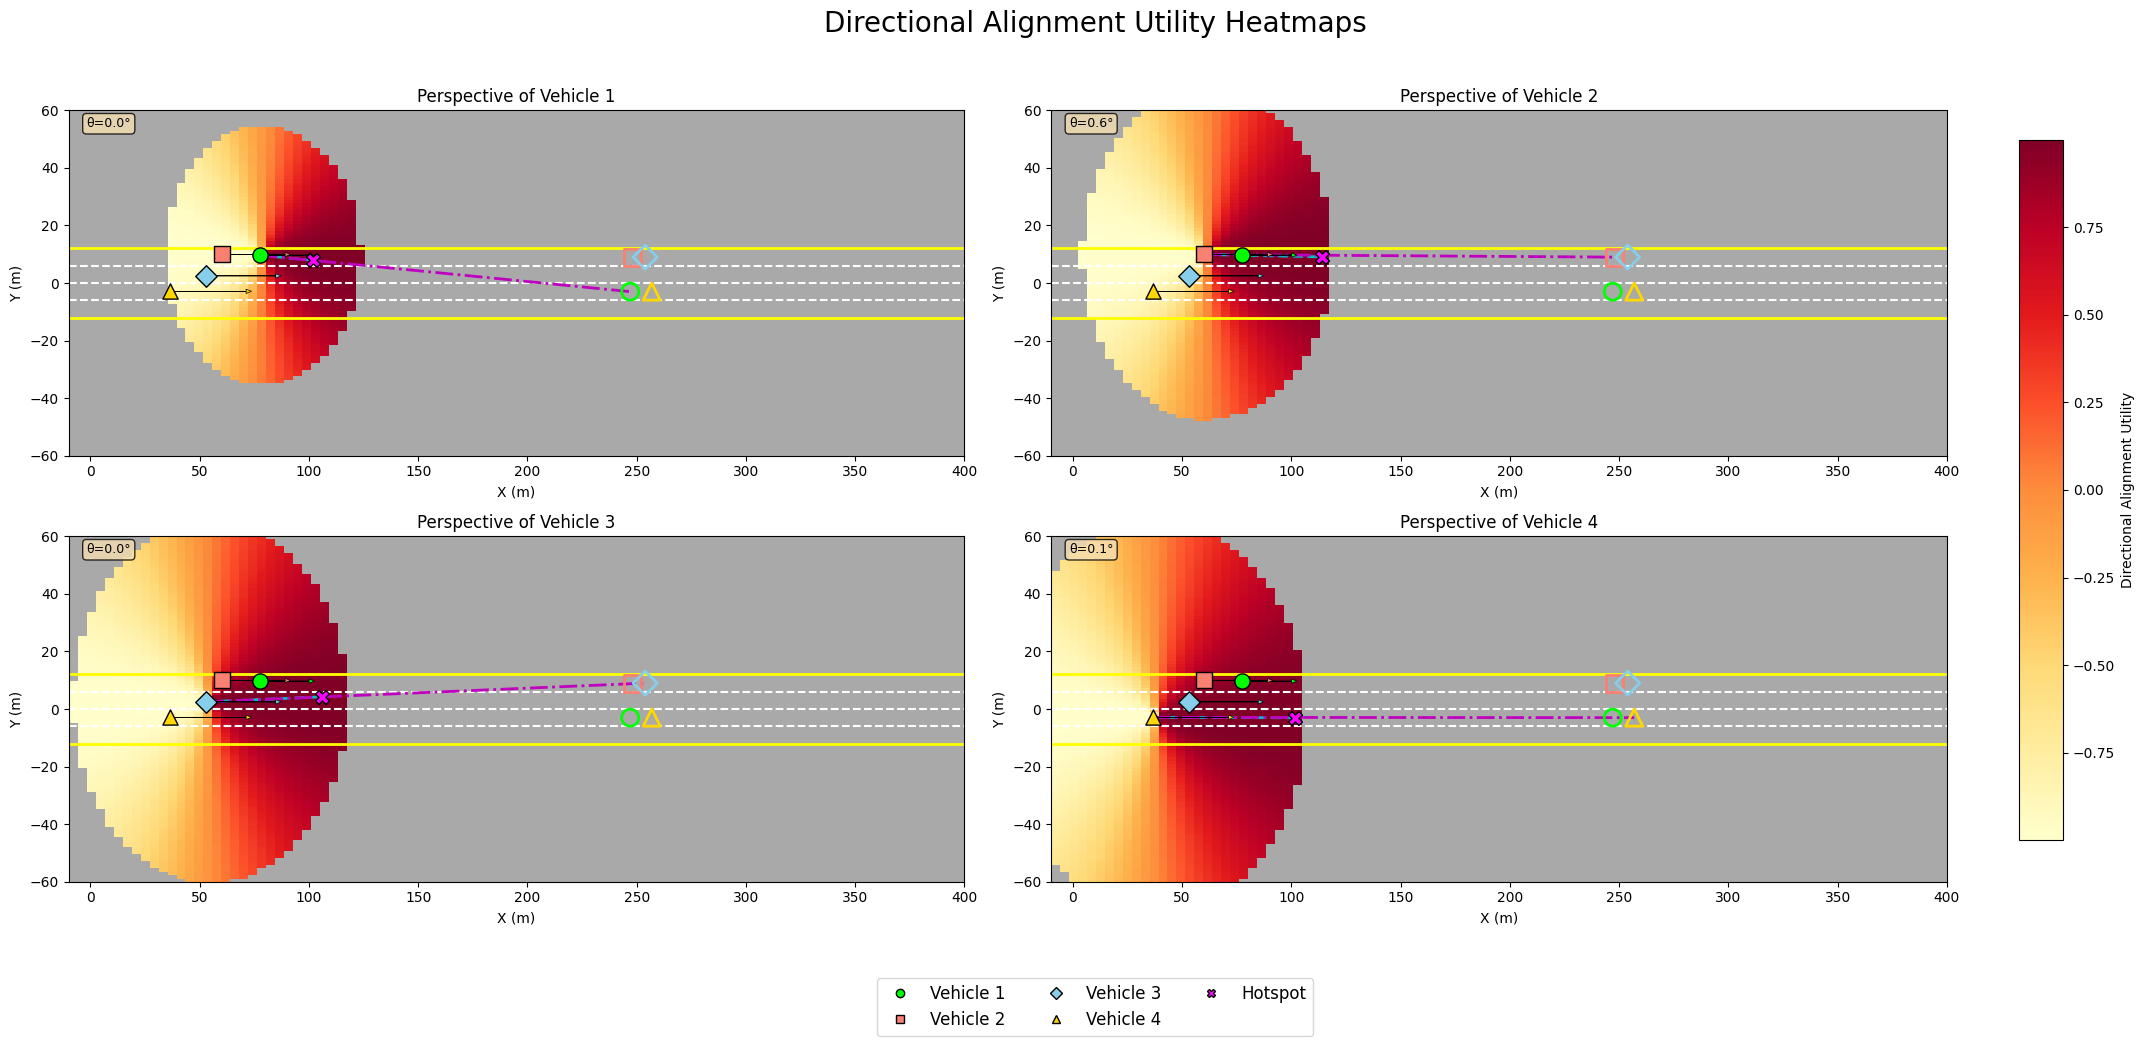

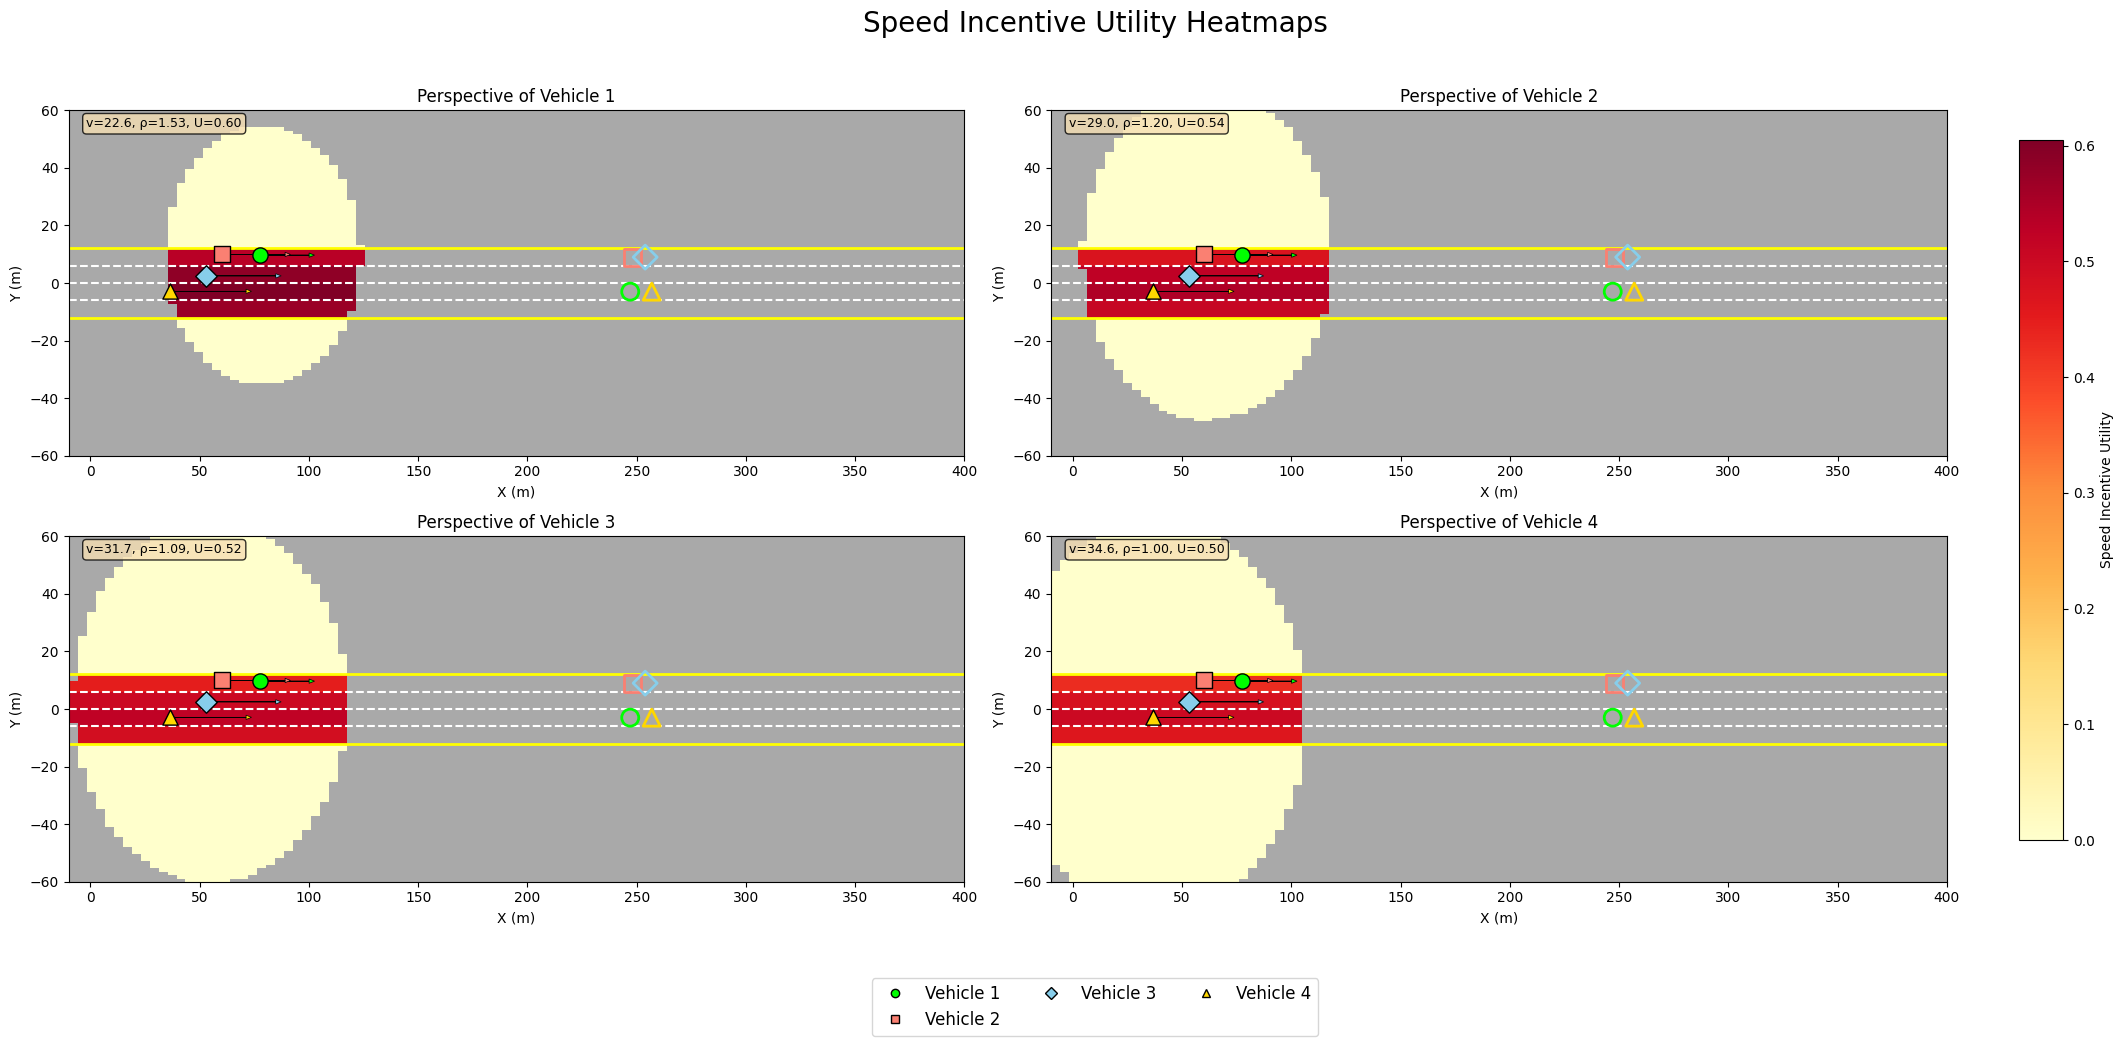

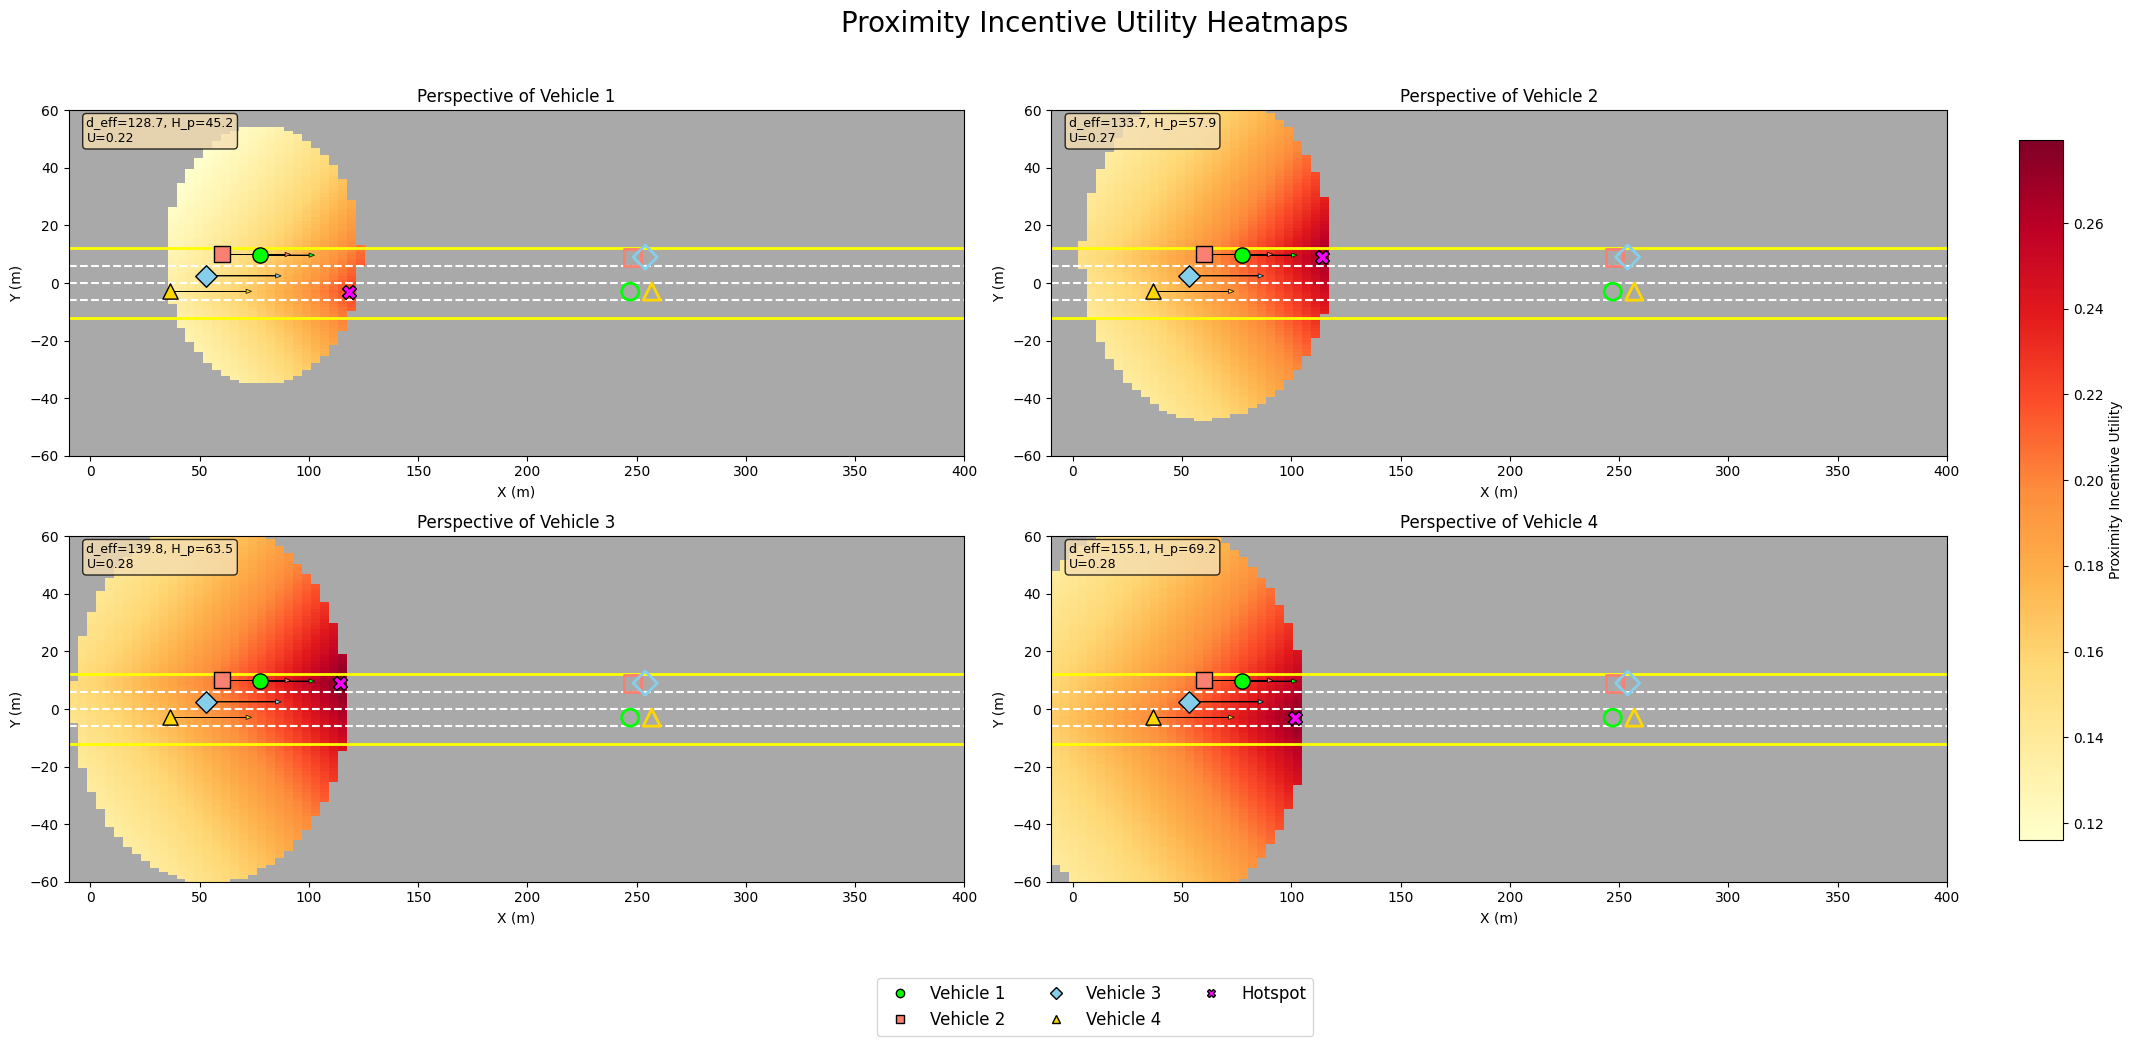

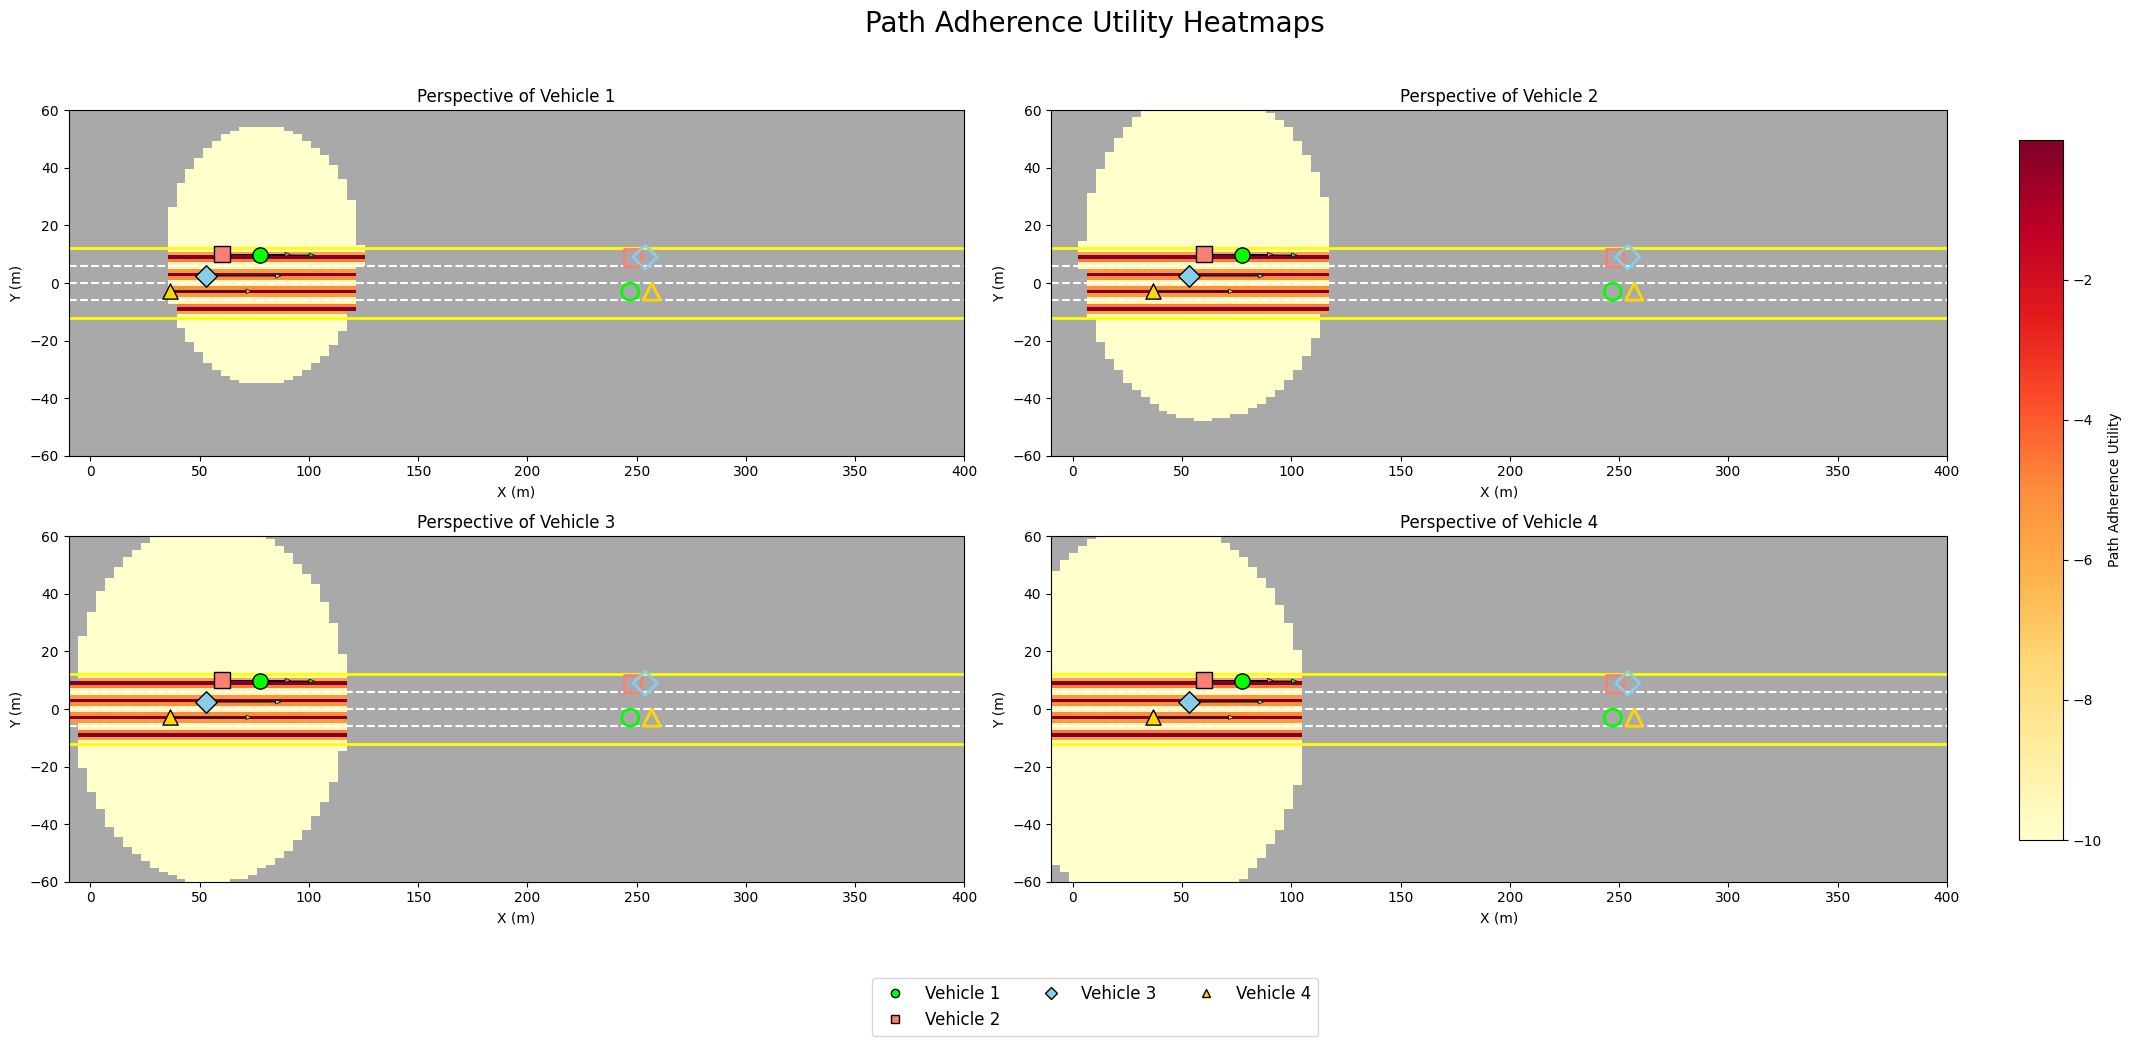

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.patches as patches

# --- 1. Setup ---
grid_size = 100
x = np.linspace(-10, 400, grid_size)
y = np.linspace(-60, 60, grid_size)

S_theta, eta_i = 1.0, 1.5
S_v, xi_i = 1.0, 3.0
S_d, gamma = 1.0, 1.2
w_ell, beta = 10.0, 0.5
kappa = 2.0
v_desired = 30.0
num_vehicles = 4
lanes = [-9, -3, 3, 9]
lane_width = 6.0
HIGHWAY_Y_MIN, HIGHWAY_Y_MAX = -12, 12

initial_vehicles = []
shapes = ['o', 's', 'D', '^']
for i in range(num_vehicles):
    assigned_lane_y = np.random.choice(lanes)
    vehicle = {
        'position': np.array([np.random.uniform(10, 80), assigned_lane_y + np.random.uniform(-1, 1)]),
        'velocity': np.array([np.random.uniform(20, 35), 0.0]),
        'target': np.array([np.random.uniform(240, 260), np.random.choice(lanes)]),
        'lane_center_y': assigned_lane_y,
        'shape': shapes[i]
    }
    initial_vehicles.append(vehicle)

# --- 2. Utility Functions ---
def calculate_directional_alignment(grid_x, grid_y, ego_vehicle):
    target_vec = np.array([ego_vehicle['target'][0] - ego_vehicle['position'][0],
                           ego_vehicle['target'][1] - ego_vehicle['position'][1]])
    target_vec /= np.linalg.norm(target_vec) + 1e-8
    cand_vec = np.array([grid_x - ego_vehicle['position'][0],
                         grid_y - ego_vehicle['position'][1]])
    cand_vec /= np.linalg.norm(cand_vec) + 1e-8
    return S_theta * np.dot(cand_vec, target_vec)

def calculate_speed_incentive(grid_y, ego_vehicle, all_vehicles):
    if not (HIGHWAY_Y_MIN <= grid_y <= HIGHWAY_Y_MAX):
        return 0.0
    v_current = np.linalg.norm(ego_vehicle['velocity'])
    lane_idx = np.argmin([abs(grid_y - center) for center in lanes])
    target_lane_center = lanes[lane_idx]
    vehicles_in_lane = [v for v in all_vehicles if abs(v['position'][1] - target_lane_center) < lane_width / 2]
    v_ref = np.mean([np.linalg.norm(v['velocity']) for v in vehicles_in_lane]) if vehicles_in_lane else v_desired
    rho_g = v_ref / max(v_current, 1e-5)
    return S_v * (rho_g / (1 + abs(rho_g) ** ((xi_i - 1) / 2)))

def calculate_proximity_incentive(grid_x, grid_y, ego_vehicle):
    v_i = np.linalg.norm(ego_vehicle['velocity'])
    H_p = kappa * v_i
    d_eff = abs(grid_x - ego_vehicle['target'][0]) + abs(grid_y - ego_vehicle['target'][1])
    return S_d / (1 + (d_eff / H_p)**gamma)
    
def calculate_path_adherence(grid_y, all_lane_centers):
    distances_to_lanes = [abs(grid_y - center) for center in all_lane_centers]
    return -w_ell * (1 - np.exp(-beta * min(distances_to_lanes)**2))

def reset_vehicles():
    return [{'position': np.copy(v['position']), 'velocity': np.copy(v['velocity']), 
             'target': np.copy(v['target']), 'lane_center_y': v['lane_center_y'],
             'shape': v['shape']} for v in initial_vehicles]

# --- 3. Helper ---
def draw_highway_layout(ax):
    ax.set_facecolor('darkgray')
    for y_val in [6, 0, -6]: ax.axhline(y_val, color='white', linestyle='--', lw=1.5)
    ax.axhline(HIGHWAY_Y_MAX, color='yellow', linestyle='-', lw=2)
    ax.axhline(HIGHWAY_Y_MIN, color='yellow', linestyle='-', lw=2)

# --- 4. Annotate details ---
def annotate_directional(ax, ego, hotspot):
    ego_pos = ego['position']
    target_vec = ego['target'] - ego_pos
    cand_vec = np.array(hotspot) - ego_pos
    theta = np.arccos(np.dot(target_vec, cand_vec) /
                      (np.linalg.norm(target_vec)*np.linalg.norm(cand_vec)+1e-8))
    theta_deg = np.degrees(theta)
    util = S_theta * np.cos(theta)
    ax.text(0.02,0.98,f"θ={theta_deg:.1f}°",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", fc="wheat", alpha=0.8))
    ax.plot([ego_pos[0], hotspot[0]],[ego_pos[1],hotspot[1]],'c--',lw=2)
    ax.plot([ego_pos[0], ego['target'][0]],[ego_pos[1], ego['target'][1]],'m-.',lw=2)

# MODIFIED: This function now accepts a y-coordinate directly instead of a hotspot tuple.
def annotate_speed(ax, ego, hotspot_y, vehicles):
    v_current = np.linalg.norm(ego['velocity'])
    lane_idx = np.argmin([abs(hotspot_y - center) for center in lanes])
    target_lane_center = lanes[lane_idx]
    vehicles_in_lane = [v for v in vehicles if abs(v['position'][1] - target_lane_center) < lane_width / 2]
    v_ref = np.mean([np.linalg.norm(v['velocity']) for v in vehicles_in_lane]) if vehicles_in_lane else v_desired
    rho_g = v_ref/max(v_current,1e-5)
    util = S_v * (rho_g / (1+abs(rho_g)**((xi_i-1)/2)))
    ax.text(0.02,0.98,f"v={v_current:.1f}, ρ={rho_g:.2f}, U={util:.2f}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", fc="wheat", alpha=0.8))

def annotate_proximity(ax, ego, hotspot):
    v_i = np.linalg.norm(ego['velocity'])
    H_p = kappa * v_i
    d_eff = abs(hotspot[0] - ego['target'][0]) + abs(hotspot[1] - ego['target'][1])
    util = S_d / (1+(d_eff/H_p)**gamma)
    ax.text(0.02,0.98,f"d_eff={d_eff:.1f}, H_p={H_p:.1f}\nU={util:.2f}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", fc="wheat", alpha=0.8))

def annotate_path(ax, hotspot):
    dists = [abs(hotspot[1]-c) for c in lanes]
    d_lane = min(dists)
    util = -w_ell*(1-np.exp(-beta*d_lane**2))

# --- 5. Plotting Function ---
def plot_utility_grid(component_name):
    vehicles = reset_vehicles()
    fig, axs = plt.subplots(2, 2, figsize=(22, 10))
    fig.suptitle(f'{component_name} Utility Heatmaps', fontsize=20)
    axs_flat = axs.flat

    styles = [{'color': 'lime', 'marker': 'o'}, {'color': 'salmon', 'marker': 's'},
              {'color': 'skyblue', 'marker': 'D'}, {'color': 'gold', 'marker': '^'}]

    matrices=[]
    for ego in vehicles:
        mat=np.full((grid_size,grid_size),np.nan)
        R=kappa*np.linalg.norm(ego['velocity'])
        for i,x_i in enumerate(x):
            for j,y_j in enumerate(y):
                if np.hypot(x_i-ego['position'][0],y_j-ego['position'][1])<=R:
                    if component_name=='Directional Alignment':
                        mat[j,i]=calculate_directional_alignment(x_i,y_j,ego)
                    elif component_name=='Speed Incentive':
                        mat[j,i]=calculate_speed_incentive(y_j,ego,vehicles)
                    elif component_name=='Proximity Incentive':
                        mat[j,i]=calculate_proximity_incentive(x_i,y_j,ego)
                    elif component_name=='Path Adherence':
                        mat[j,i]=calculate_path_adherence(y_j,lanes)
        matrices.append(mat)

    gmin,gmax=np.nanmin(matrices),np.nanmax(matrices)

    for idx,ax in enumerate(axs_flat):
        ego=vehicles[idx]; mat=matrices[idx]
        draw_highway_layout(ax)
        cax=ax.imshow(mat,extent=[x.min(),x.max(),y.min(),y.max()],
                       origin='lower',cmap="YlOrRd",aspect='auto',
                       vmin=gmin,vmax=gmax)
        
        # MODIFIED: Logic now handles annotation for Speed Incentive separately.
        if not np.all(np.isnan(mat)):
            # Plot hotspot marker and text for these components
            if component_name in ["Directional Alignment", "Proximity Incentive"]:
                max_idx = np.unravel_index(np.nanargmax(mat), mat.shape)
                hotspot = (x[max_idx[1]], y[max_idx[0]])
                ax.scatter(*hotspot, marker='X', s=100, color='magenta', edgecolor='black', zorder=12)
                
                if component_name == "Directional Alignment":
                    annotate_directional(ax, ego, hotspot)
                elif component_name == "Proximity Incentive":
                    annotate_proximity(ax, ego, hotspot)
            
            # For Speed Incentive, just add the annotation text without the marker
            elif component_name == "Speed Incentive":
                max_idx = np.unravel_index(np.nanargmax(mat), mat.shape)
                hotspot_y = y[max_idx[0]] # Get the y-coordinate of max utility
                annotate_speed(ax, ego, hotspot_y, vehicles)


        # vehicles
        for i,v in enumerate(vehicles):
            style=styles[i]
            ax.scatter(v['position'][0],v['position'][1],color=style['color'],
                       s=120,marker=style['marker'],edgecolors='black',zorder=10)
            vx,vy=v['velocity']
            ax.arrow(v['position'][0],v['position'][1],vx,vy,
                     head_width=1.5,head_length=2.5,fc=style['color'],
                     ec='black',lw=0.5,zorder=9)
            ax.scatter(v['target'][0],v['target'][1],s=150,marker=style['marker'],
                       facecolors='none',edgecolors=style['color'],lw=2,zorder=10)

        ax.set_title(f'Perspective of Vehicle {idx+1}')
        ax.set_xlim(x.min(),x.max()); ax.set_ylim(y.min(),y.max())
        ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")

    cbar_ax=fig.add_axes([0.92,0.15,0.02,0.7])
    fig.colorbar(cax,cax=cbar_ax,label=f'{component_name} Utility')

    legend_handles=[
        Line2D([0],[0],marker='o',color='w',label='Vehicle 1',markerfacecolor='lime',markeredgecolor='black'),
        Line2D([0],[0],marker='s',color='w',label='Vehicle 2',markerfacecolor='salmon',markeredgecolor='black'),
        Line2D([0],[0],marker='D',color='w',label='Vehicle 3',markerfacecolor='skyblue',markeredgecolor='black'),
        Line2D([0],[0],marker='^',color='w',label='Vehicle 4',markerfacecolor='gold',markeredgecolor='black'),
    ]
    
    if component_name in ["Directional Alignment", "Proximity Incentive"]:
        legend_handles.append(
            Line2D([0],[0],marker='X',color='w',label='Hotspot',markerfacecolor='magenta',markeredgecolor='black')
        )

    fig.legend(handles=legend_handles,loc='upper center',bbox_to_anchor=(0.5,0.02),fontsize=12,ncol=3)

    plt.tight_layout(rect=[0,0.05,0.9,0.96]); plt.show()

# --- 6. Run ---
utility_components_to_plot = ['Directional Alignment','Speed Incentive','Proximity Incentive','Path Adherence']
for comp in utility_components_to_plot:
    plot_utility_grid(comp)

In [ ]:
### Sensitivity Section ###

Generating 1 heatmaps for Directional Alignment Utility...


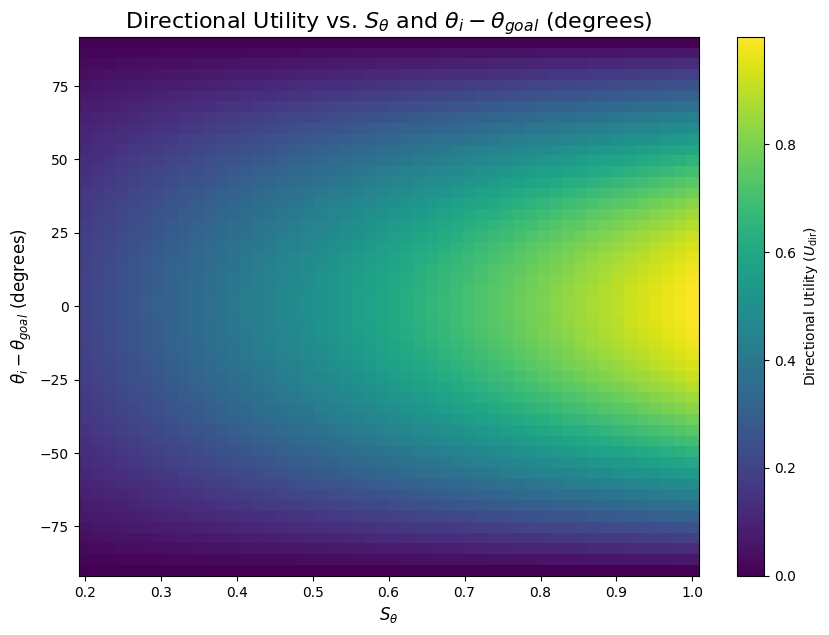

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import itertools

def directional_utility(S_theta, theta_i_deg):
    """Directional utility (paper Eq. 5): U_dir = S_theta * cos(theta - theta_goal).
    theta_i_deg is the heading error (theta - theta_goal) in degrees."""
    theta_i_rad = np.deg2rad(theta_i_deg)
    return S_theta * np.cos(theta_i_rad)

# --- Define parameters to vary ---
params_to_vary = {
    'S_theta': np.linspace(0.2, 1.0, 50),
    'theta_i_deg': np.linspace(-90, 90, 50)
}

# Fixed values
fixed_values = {'S_theta': 1.0, 'theta_i_deg': 0}

# --- Generate parameter pairs ---
param_pairs = list(itertools.combinations(params_to_vary.keys(), 2))
print(f"Generating {len(param_pairs)} heatmaps for Directional Alignment Utility...")

# --- Mapping for pretty LaTeX labels ---
label_map = {
    'S_theta': r'$S_\theta$',
    'theta_i_deg': r'$\theta_i - \theta_{goal}$ (degrees)'
}

# --- Plot loop ---
for x_param, y_param in param_pairs:
    X_grid, Y_grid = np.meshgrid(params_to_vary[x_param], params_to_vary[y_param])
    
    func_args = fixed_values.copy()
    func_args[x_param] = X_grid
    func_args[y_param] = Y_grid
    
    utility_grid = directional_utility(**func_args)
    
    plt.figure(figsize=(10, 7))
    c = plt.pcolormesh(X_grid, Y_grid, utility_grid, cmap='viridis', shading='auto')
    plt.colorbar(c, label=r'Directional Utility ($U_{\mathrm{dir}}$)')
    plt.title(rf'Directional Utility vs. {label_map[x_param]} and {label_map[y_param]}', fontsize=16)
    plt.xlabel(label_map[x_param], fontsize=12)
    plt.ylabel(label_map[y_param], fontsize=12)
    plt.show()


Generating 1 heatmaps for Speed Incentive Utility...


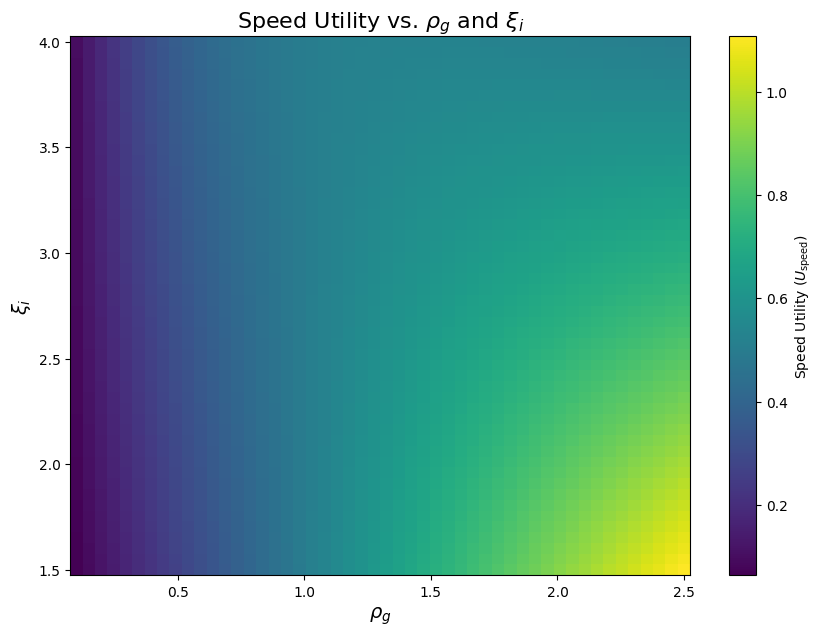

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import itertools

def speed_utility(S_v, rho_g, xi_i):
    """Calculates speed incentive utility."""
    return S_v * (rho_g / (1 + np.abs(rho_g) ** ((xi_i - 1) / 2)))

# --- Define parameters to vary ---
params_to_vary = {
    'rho_g': np.linspace(0.1, 2.5, 50),
    'xi_i': np.linspace(1.5, 4.0, 50)
}

# Fixed values
fixed_values = {'S_v': 1.0, 'rho_g': 1.1, 'xi_i': 2.5}

# --- Generate all unique pairs of parameters ---
param_pairs = list(itertools.combinations(params_to_vary.keys(), 2))
print(f"Generating {len(param_pairs)} heatmaps for Speed Incentive Utility...")

# --- Mapping for LaTeX-style axis labels ---
label_map = {
    'rho_g': r'$\rho_g$',
    'xi_i': r'$\xi_i$'
}

# --- Loop through pairs and plot ---
for x_param, y_param in param_pairs:
    X_grid, Y_grid = np.meshgrid(params_to_vary[x_param], params_to_vary[y_param])
    
    func_args = fixed_values.copy()
    func_args[x_param] = X_grid
    func_args[y_param] = Y_grid
    
    utility_grid = speed_utility(**func_args)
    
    plt.figure(figsize=(10, 7))
    c = plt.pcolormesh(X_grid, Y_grid, utility_grid, cmap='viridis', shading='auto')
    plt.colorbar(c, label=r'Speed Utility ($U_{\mathrm{speed}}$)')
    plt.title(rf'Speed Utility vs. {label_map[x_param]} and {label_map[y_param]}', fontsize=16)
    plt.xlabel(label_map[x_param], fontsize=14)
    plt.ylabel(label_map[y_param], fontsize=14)
    plt.show()


Generating 3 heatmaps for Proximity Incentive Utility...


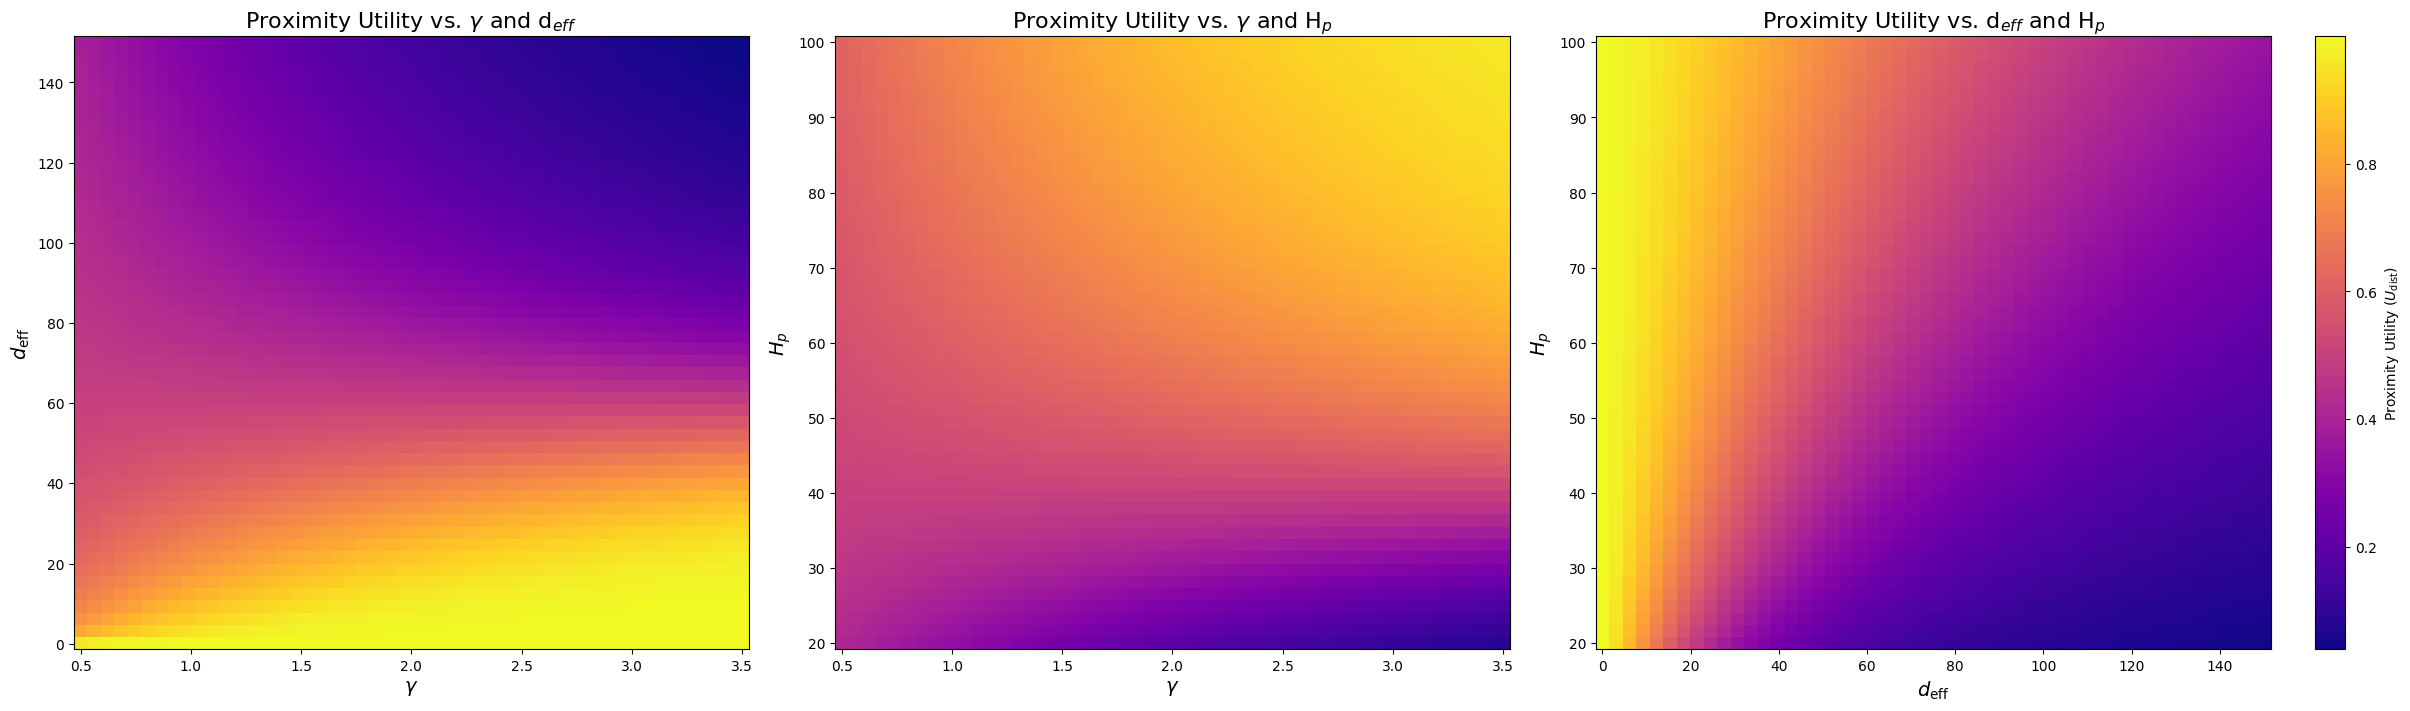

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import itertools

def proximity_utility(S_d, gamma, d_eff, H_p):
    """Calculates proximity incentive utility."""
    H_p = np.maximum(H_p, 1e-6)
    term = d_eff / H_p
    return S_d / (1 + term**gamma)

# --- Define parameters to vary ---
params_to_vary = {
    'gamma': np.linspace(0.5, 3.5, 50),
    'd_eff': np.linspace(0.1, 150, 50),
    'H_p': np.linspace(20, 100, 50)
}

fixed_values = {'S_d': 1.0, 'gamma': 1.5, 'd_eff': 40.0, 'H_p': 60.0}

# --- Generate all unique pairs of parameters ---
param_pairs = list(itertools.combinations(params_to_vary.keys(), 2))
print(f"Generating {len(param_pairs)} heatmaps for Proximity Incentive Utility...")

# --- LaTeX-style axis labels and display names ---
label_map = {
    'gamma': r'$\gamma$',
    'd_eff': r'$d_{\mathrm{eff}}$',
    'H_p': r'$H_p$'
}

display_map = {
    'gamma': r'$\gamma$',
    'd_eff': r'd$_{eff}$',
    'H_p': r'H$_p$'
}

# --- Create figure with 1x3 layout ---
fig, axes = plt.subplots(1, 3, figsize=(24, 7), constrained_layout=True)

# --- Compute global min/max for consistent color scale ---
vmin, vmax = None, None
for x_param, y_param in param_pairs:
    X_grid, Y_grid = np.meshgrid(params_to_vary[x_param], params_to_vary[y_param])
    func_args = fixed_values.copy()
    func_args[x_param] = X_grid
    func_args[y_param] = Y_grid
    utility_grid = proximity_utility(**func_args)
    vmin = utility_grid.min() if vmin is None else min(vmin, utility_grid.min())
    vmax = utility_grid.max() if vmax is None else max(vmax, utility_grid.max())

# --- Plot each subplot ---
mappables = []
for ax, (x_param, y_param) in zip(axes, param_pairs):
    X_grid, Y_grid = np.meshgrid(params_to_vary[x_param], params_to_vary[y_param])
    func_args = fixed_values.copy()
    func_args[x_param] = X_grid
    func_args[y_param] = Y_grid
    utility_grid = proximity_utility(**func_args)

    c = ax.pcolormesh(X_grid, Y_grid, utility_grid, cmap='plasma', shading='auto', vmin=vmin, vmax=vmax)
    mappables.append(c)
    
    # --- Updated title formatting ---
    ax.set_title(f'Proximity Utility vs. {display_map[x_param]} and {display_map[y_param]}', fontsize=16)
    ax.set_xlabel(label_map[x_param], fontsize=14)
    ax.set_ylabel(label_map[y_param], fontsize=14)

# --- Add shared colorbar ---
fig.colorbar(mappables[-1], ax=axes, orientation='vertical', fraction=0.025, pad=0.02,
              label=r'Proximity Utility ($U_{\mathrm{dist}}$)')

plt.show()


Generating 1 heatmaps for Collision Utility...


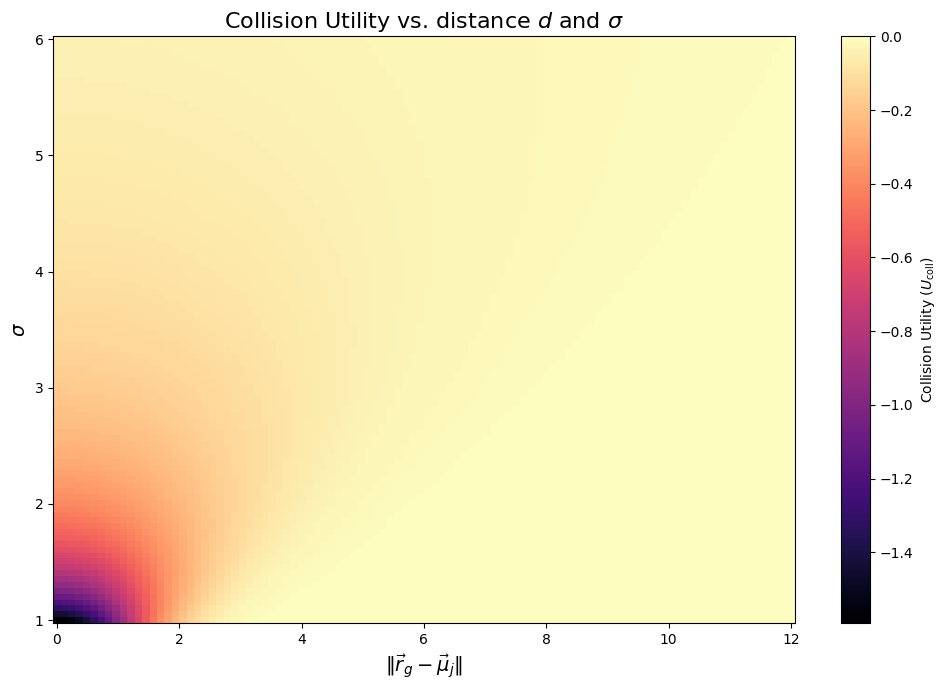

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import itertools

def collision_utility(w_c, d, sigma):
    """Collision-risk penalty (paper Eqs. 10-12): U_col = W_cc * P_{i,g}, where
    P_{i,g} is the Gaussian presence probability of a neighbor occupying the
    candidate point. With an isotropic 2D covariance Sigma = sigma^2 * I:
        (2*pi)^(d/2) = 2*pi,  |Sigma|^(1/2) = sigma^2,  Mahalanobis^2 = (d/sigma)^2
    d is the distance ||r_g - mu_j|| to the neighbor's predicted mean position."""
    sigma = np.maximum(sigma, 1e-6)
    pdf_norm = 1.0 / (2 * np.pi * sigma**2)
    prob_coll = pdf_norm * np.exp(-0.5 * (d / sigma)**2)
    return -w_c * prob_coll

# --- Define parameters to vary ---
# Avoid very small sigma values: they create a sharp PDF spike at d=0 that
# compresses the rest of the heatmap into nearly one color.
params_to_vary = {
    'd': np.linspace(0.0, 12.0, 100),
    'sigma': np.linspace(1.0, 6.0, 100)
}

fixed_values = {'w_c': 10.0, 'd': 3.0, 'sigma': 3.0}

# --- Generate all unique pairs of parameters ---
param_pairs = list(itertools.combinations(params_to_vary.keys(), 2))
print(f"Generating {len(param_pairs)} heatmaps for Collision Utility...")

# --- LaTeX-style axis labels and display names ---
label_map = {
    'd': r'$\|\vec r_g - \vec \mu_j\|$',
    'sigma': r'$\sigma$'
}

display_map = {
    'd': r'distance $d$',
    'sigma': r'$\sigma$'
}

# --- Create figure ---
fig, ax = plt.subplots(figsize=(10, 7))

# --- Plot heatmap ---
for x_param, y_param in param_pairs:
    X_grid, Y_grid = np.meshgrid(params_to_vary[x_param], params_to_vary[y_param])
    func_args = fixed_values.copy()
    func_args[x_param] = X_grid
    func_args[y_param] = Y_grid
    utility_grid = collision_utility(**func_args)

    c = ax.pcolormesh(X_grid, Y_grid, utility_grid, cmap='magma', shading='auto')
    ax.set_title(f'Collision Utility vs. {display_map[x_param]} and {display_map[y_param]}', fontsize=16)
    ax.set_xlabel(label_map[x_param], fontsize=14)
    ax.set_ylabel(label_map[y_param], fontsize=14)

# --- Add colorbar ---
fig.colorbar(c, ax=ax, label=r'Collision Utility ($U_{\mathrm{coll}}$)')

plt.tight_layout()
plt.show()


Generating 1 heatmaps for Path Adherence Utility...


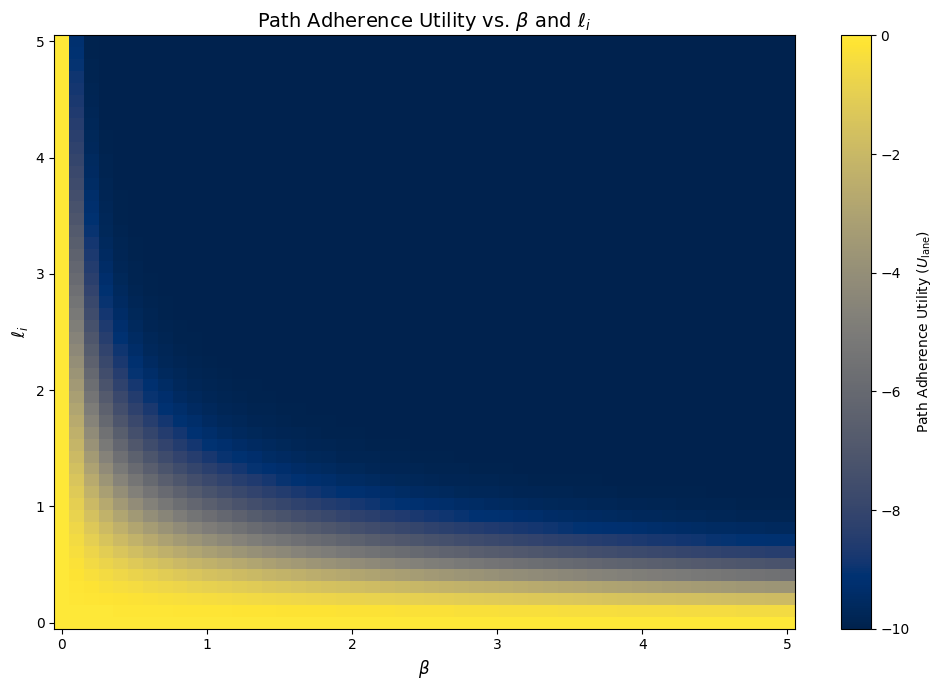

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import itertools

def path_adherence_utility(w_ell, beta, ell_i):
    """Calculates path adherence penalty."""
    return -w_ell * (1 - np.exp(-beta * ell_i**2))

# --- Define parameters to vary ---
params_to_vary = {
    'beta': np.linspace(0, 5.0, 50),
    'ell_i': np.linspace(0, 5, 50)
}

# Fixed values
fixed_values = {'w_ell': 10.0, 'beta': 0.5, 'ell_i': 3.0}

# --- Generate all unique pairs of parameters ---
param_pairs = list(itertools.combinations(params_to_vary.keys(), 2))
print(f"Generating {len(param_pairs)} heatmaps for Path Adherence Utility...")

# --- LaTeX-style axis labels and display names ---
label_map = {
    'beta': r'$\beta$',
    'ell_i': r'$\ell_i$'
}

display_map = {
    'beta': r'$\beta$',
    'ell_i': r'$\ell_i$'
}

# --- Create figure ---
fig, ax = plt.subplots(figsize=(10, 7))

# --- Plot ---
for x_param, y_param in param_pairs:
    X_grid, Y_grid = np.meshgrid(params_to_vary[x_param], params_to_vary[y_param])
    
    func_args = fixed_values.copy()
    func_args[x_param] = X_grid
    func_args[y_param] = Y_grid
    
    utility_grid = path_adherence_utility(**func_args)
    
    c = ax.pcolormesh(X_grid, Y_grid, utility_grid, cmap='cividis', shading='auto')
    
    # --- Updated title formatting ---
    ax.set_title(f'Path Adherence Utility vs. {display_map[x_param]} and {display_map[y_param]}', fontsize=14)
    ax.set_xlabel(label_map[x_param], fontsize=12)
    ax.set_ylabel(label_map[y_param], fontsize=12)

# --- Add colorbar ---
fig.colorbar(c, ax=ax, label=r'Path Adherence Utility ($U_{\mathrm{lane}}$)')

plt.tight_layout()
plt.show()
